In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

DATA_PATH = "/kaggle/input/datasets/matanerdy/kurgan-dataset/dataset_multi_full_non_binary_сrop/metadata.csv"
IMAGES_DIR = "/kaggle/input/datasets/matanerdy/kurgan-dataset/dataset_multi_full_non_binary_сrop/images"
MASKS_DIR = "/kaggle/input/datasets/matanerdy/kurgan-dataset/dataset_multi_full_non_binary_сrop/masks"

In [ ]:
meta = pd.read_csv(DATA_PATH)

print(meta["kurgan_type"].value_counts())

kurgan_type
damaged    1822
whole       669
Name: count, dtype: int64


In [3]:
meta

,sample_id,region,modality,raster_file,kurgan_type,n_objects_in_patch,height,width,crop_size,obj_w_px,obj_h_px,target_fits_inside,touches_border,used_crs_fallback,mask_bg_pixels,mask_whole_pixels,mask_damaged_pixels,has_whole,has_damaged
0,0,007_ЮШКОВО,Li,03_Юшково_Li_карты_g.tif,whole,2,292,292,292,137.846687,145.870188,True,False,False,65385,19879,0,True,False
1,1,007_ЮШКОВО,Li,03_Юшково_Li_карты_g.tif,whole,3,256,256,256,67.590416,94.949307,True,False,False,51116,14420,0,True,False
2,2,007_ЮШКОВО,Li,03_Юшково_Li_карты_g.tif,whole,11,368,368,368,144.298633,183.356549,True,False,False,69648,40977,24799,True,True
3,3,007_ЮШКОВО,Li,03_Юшково_Li_карты_g.tif,whole,2,256,256,256,89.852492,95.168255,True,False,False,52645,6543,6348,True,True
4,4,007_ЮШКОВО,Li,03_Юшково_Li_карты_g.tif,whole,9,256,256,256,126.731663,98.923194,True,False,False,16451,32423,16662,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2486,2486,131_Курганы_12,SpOr,01_Курганы_12_SpOr_спутник.tif,damaged,2,256,256,256,71.211849,78.908398,True,False,False,59894,0,5642,False,True
2487,2487,131_Курганы_12,SpOr,01_Курганы_12_SpOr_спутник.tif,damaged,2,256,256,256,40.716662,37.472662,True,False,False,59894,0,5642,False,True
2488,2488,131_Курганы_12,SpOr,01_Курганы_12_SpOr_спутник.tif,damaged,3,256,256,256,66.791060,60.019545,True,False,False,61221,0,4315,False,True
2489,2489,131_Курганы_12,SpOr,01_Курганы_12_SpOr_спутник.tif,damaged,3,256,256,256,25.717889,27.866839,True,False,False,61221,0,4315,False,True


In [ ]:
from pathlib import Path
import cv2
import torch
from torch.utils.data import Dataset


class KurganDataset(Dataset):
    def __init__(
        self,
        meta_df,
        images_dir,
        masks_dir,
        target_size=256,
        normalize="zscore",
        transform=None,
    ):
        self.meta = meta_df.reset_index(drop=True).copy()
        self.images_dir = Path(images_dir)
        self.masks_dir = Path(masks_dir)
        self.target_size = target_size
        self.normalize = normalize
        self.transform = transform

    def __len__(self):
        return len(self.meta)

    def _normalize_patch(self, patch: np.ndarray) -> np.ndarray:
        patch = patch.astype(np.float32)

        if self.normalize == "zscore":
            mean = patch.mean()
            std = patch.std()
            if std < 1e-6:
                std = 1.0
            patch = (patch - mean) / std

        elif self.normalize == "minmax":
            pmin = patch.min()
            pmax = patch.max()
            if pmax - pmin < 1e-6:
                patch = np.zeros_like(patch, dtype=np.float32)
            else:
                patch = (patch - pmin) / (pmax - pmin)

        elif self.normalize is None:
            pass

        else:
            raise ValueError(f"Unknown normalize mode: {self.normalize}")

        return patch

    def __getitem__(self, idx):
        row = self.meta.iloc[idx]
        sample_id = str(row["sample_id"]).zfill(6)

        patch = np.load(self.images_dir / f"{sample_id}.npy")
        mask = np.load(self.masks_dir / f"{sample_id}.npy")

        if self.target_size is not None:
            if patch.shape != (self.target_size, self.target_size):
                patch = cv2.resize(
                    patch,
                    (self.target_size, self.target_size),
                    interpolation=cv2.INTER_LINEAR
                )

            if mask.shape != (self.target_size, self.target_size):
                mask = cv2.resize(
                    mask,
                    (self.target_size, self.target_size),
                    interpolation=cv2.INTER_NEAREST
                )

        if self.transform is not None:
            patch, mask = self.transform(patch, mask)

        patch = np.asarray(patch, dtype=np.float32)
        mask = np.asarray(mask, dtype=np.int64)

        unique_vals = np.unique(mask)
        if not np.all(np.isin(unique_vals, [0, 1, 2])):
            raise ValueError(f"Unexpected mask values for sample {sample_id}: {unique_vals}")

        patch = self._normalize_patch(patch)

        patch = torch.from_numpy(patch).float().unsqueeze(0)  # [1, H, W]
        mask = torch.from_numpy(mask).long()                  # [H, W]

        sample = {
            "image": patch,
            "mask": mask,
            "sample_id": sample_id,
            "region": row["region"],
            "modality": row["modality"],
            "raster_file": row["raster_file"],
            "kurgan_type": row["kurgan_type"],
            "n_objects_in_patch": int(row["n_objects_in_patch"]),
            "height": float(row["height"]),
            "width": float(row["width"]),
        }

        optional_cols = [
            "used_crs_fallback",
            "mask_bg_pixels",
            "mask_whole_pixels",
            "mask_damaged_pixels",
            "has_whole",
            "has_damaged",
            "touches_border",
            "patch_size",
        ]

        for col in optional_cols:
            if col in row.index:
                sample[col] = row[col]

        return sample

Dataset size: 2491
torch.Size([1, 256, 256])
torch.Size([256, 256])
tensor([0, 1, 2])
batch image shape: torch.Size([16, 1, 256, 256])
batch mask shape: torch.Size([16, 256, 256])
mask unique values: tensor([0, 1, 2])


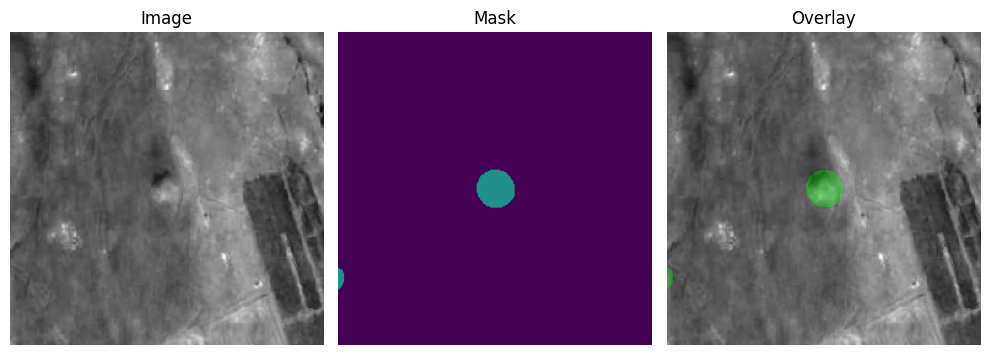

In [ ]:
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

dataset = KurganDataset(
    meta_df=meta,
    images_dir=IMAGES_DIR,
    masks_dir=MASKS_DIR,
    target_size=256,
    normalize="zscore",
)

print("Dataset size:", len(dataset))

sample = dataset[4]
print(sample["image"].shape)   # [1, 256, 256]
print(sample["mask"].shape)    # [256, 256]
print(torch.unique(sample["mask"]))

loader = DataLoader(dataset, batch_size=16, shuffle=True)

batch = next(iter(loader))
print("batch image shape:", batch["image"].shape)   # [B, 1, 256, 256]
print("batch mask shape:", batch["mask"].shape)  # [B, 256, 256]
print("mask unique values:", torch.unique(batch["mask"]))

# visualize one sample from batch
img = batch["image"][0, 0].numpy()
msk = batch["mask"][0].numpy()

overlay = np.zeros((*msk.shape, 4), dtype=np.float32)
overlay[msk == 1] = [0.0, 1.0, 0.0, 0.35]
overlay[msk == 2] = [1.0, 0.0, 0.0, 0.35]

plt.figure(figsize=(10, 4))

plt.subplot(1, 3, 1)
plt.title("Image")
plt.imshow(img, cmap="gray")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title("Mask")
plt.imshow(msk, vmin=0, vmax=2)
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title("Overlay")
plt.imshow(img, cmap="gray")
plt.imshow(overlay)
plt.axis("off")

plt.tight_layout()
plt.show()

In [6]:
import torch
import torch.nn as nn

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class UNetSmall(nn.Module):
    def __init__(self, in_channels=1, out_channels=1):
        super().__init__()

        self.enc1 = DoubleConv(in_channels, 32)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = DoubleConv(32, 64)
        self.pool2 = nn.MaxPool2d(2)

        self.enc3 = DoubleConv(64, 128)
        self.pool3 = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(128, 256)

        self.up3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(256, 128)

        self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(128, 64)

        self.up1 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(64, 32)

        self.out_conv = nn.Conv2d(32, out_channels, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))

        b = self.bottleneck(self.pool3(e3))

        d3 = self.up3(b)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.out_conv(d1)

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class MultiClassDiceLoss(nn.Module):
    def __init__(self, num_classes=3, smooth=1e-6, ignore_background=True):
        super().__init__()
        self.num_classes = num_classes
        self.smooth = smooth
        self.ignore_background = ignore_background

    def forward(self, logits, targets):
        probs = torch.softmax(logits, dim=1)  # [B, C, H, W]
        targets_oh = F.one_hot(targets, num_classes=self.num_classes)  # [B, H, W, C]
        targets_oh = targets_oh.permute(0, 3, 1, 2).float()            # [B, C, H, W]

        dims = (0, 2, 3)
        intersection = (probs * targets_oh).sum(dims)
        union = probs.sum(dims) + targets_oh.sum(dims)

        dice = (2.0 * intersection + self.smooth) / (union + self.smooth)

        if self.ignore_background:
            dice = dice[1:]

        return 1.0 - dice.mean()


class CombinedMultiClassLoss(nn.Module):
    def __init__(
        self,
        num_classes=3,
        ce_weight=0.5,
        dice_weight=0.5,
        class_weights=None,
    ):
        super().__init__()
        self.ce_weight = ce_weight
        self.dice_weight = dice_weight

        if class_weights is not None:
            class_weights = torch.tensor(class_weights, dtype=torch.float32)
        self.register_buffer(
            "class_weights",
            class_weights if class_weights is not None else None
        )

        self.ce_loss = nn.CrossEntropyLoss(weight=self.class_weights)
        self.dice_loss = MultiClassDiceLoss(num_classes=num_classes)

    def forward(self, logits, targets):
        ce = self.ce_loss(logits, targets)
        dice = self.dice_loss(logits, targets)

        total = self.ce_weight * ce + self.dice_weight * dice
        return total, {
            "ce": ce.item(),
            "dice": dice.item(),
        }


def per_class_iou(logits, targets, num_classes=3, smooth=1e-6):
    preds = torch.argmax(logits, dim=1)
    out = {}

    for cls in range(num_classes):
        pred_cls = (preds == cls).float()
        target_cls = (targets == cls).float()

        intersection = (pred_cls * target_cls).sum(dim=(1, 2))
        union = pred_cls.sum(dim=(1, 2)) + target_cls.sum(dim=(1, 2)) - intersection
        iou = (intersection + smooth) / (union + smooth)
        out[cls] = iou.mean().item()

    return out


def per_class_dice(logits, targets, num_classes=3, smooth=1e-6):
    preds = torch.argmax(logits, dim=1)
    out = {}

    for cls in range(num_classes):
        pred_cls = (preds == cls).float()
        target_cls = (targets == cls).float()

        intersection = (pred_cls * target_cls).sum(dim=(1, 2))
        union = pred_cls.sum(dim=(1, 2)) + target_cls.sum(dim=(1, 2))
        dice = (2 * intersection + smooth) / (union + smooth)
        out[cls] = dice.mean().item()

    return out


def mean_fg_iou(logits, targets):
    cls_iou = per_class_iou(logits, targets, num_classes=3)
    return (cls_iou[1] + cls_iou[2]) / 2.0


def mean_fg_dice(logits, targets):
    cls_dice = per_class_dice(logits, targets, num_classes=3)
    return (cls_dice[1] + cls_dice[2]) / 2.0

In [8]:
def evaluate(model, loader, criterion, device):
    model.eval()

    total_loss = 0.0
    total_dice = 0.0
    total_iou = 0.0
    n_batches = 0

    per_cls_dice_sum = {0: 0.0, 1: 0.0, 2: 0.0}
    per_cls_iou_sum = {0: 0.0, 1: 0.0, 2: 0.0}

    with torch.no_grad():
        for batch in loader:
            images = batch["image"].to(device)   # [B, 1, H, W]
            masks = batch["mask"].to(device)     # [B, H, W]

            logits = model(images)
            loss, _ = criterion(logits, masks)

            total_loss += loss.item()
            total_dice += mean_fg_dice(logits, masks)
            total_iou += mean_fg_iou(logits, masks)

            cls_dice = per_class_dice(logits, masks, num_classes=3)
            cls_iou = per_class_iou(logits, masks, num_classes=3)

            for k in per_cls_dice_sum:
                per_cls_dice_sum[k] += cls_dice[k]
                per_cls_iou_sum[k] += cls_iou[k]

            n_batches += 1

    metrics = {
        "loss": total_loss / n_batches,
        "mean_fg_dice": total_dice / n_batches,
        "mean_fg_iou": total_iou / n_batches,
        "dice_bg": per_cls_dice_sum[0] / n_batches,
        "dice_whole": per_cls_dice_sum[1] / n_batches,
        "dice_damaged": per_cls_dice_sum[2] / n_batches,
        "iou_bg": per_cls_iou_sum[0] / n_batches,
        "iou_whole": per_cls_iou_sum[1] / n_batches,
        "iou_damaged": per_cls_iou_sum[2] / n_batches,
    }
    return metrics

In [9]:
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from tqdm import tqdm

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

meta = pd.read_csv(DATA_PATH)

print(meta["kurgan_type"].value_counts())
print(meta["region"].value_counts())

kurgan_type
damaged    1822
whole       669
Name: count, dtype: int64
region
027_ТИМЕРЕВО                             885
042_ИЗБОРСК                              154
044_ГОЧЕВО                               105
033_МИЛОВИДОВО_0.1км                      99
007_ЮШКОВО                                83
047_КАЛМЫКИЯ_1                            82
008_СЕЛЯНЕ                                81
017_ВЫШЕГЖА                               71
046_ТЫВА_2                                63
058_СЕЛЬЦО                                62
055_КАБАРДИНО-БАЛКАРИЯ                    60
121_Курганы_2                             52
010_НОВЕНЬКОЕ                             47
026_БОРОВИЧИ                              44
054_КУРМЕНТУ                              37
028_САРАТОВ                               34
120_Курганы_1                             33
122_Курганы_3                             28
123_Курганы_4                             27
048_КАЛМЫКИЯ_2                            27
039_САРСКОЕ            

In [11]:
val_regions = [
    "042_ИЗБОРСК",
    "044_ГОЧЕВО",
    "033_МИЛОВИДОВО_0.1км",
    "007_ЮШКОВО",
    "047_КАЛМЫКИЯ_1",
    "008_СЕЛЯНЕ",
    "025_ШУМГОРА"
]

train_df = meta[~meta["region"].isin(val_regions)].copy()
val_df = meta[meta["region"].isin(val_regions)].copy()

In [12]:
print(len(train_df), len(val_df))
print(train_df["kurgan_type"].value_counts())
print(val_df["kurgan_type"].value_counts())
print(val_df["region"].value_counts())

print("Train ", train_df["modality"].value_counts())
print(pd.crosstab(train_df["modality"], train_df["kurgan_type"]))
print("Val ", val_df["modality"].value_counts())
print(pd.crosstab(val_df["modality"], val_df["kurgan_type"]))

print("Train ", train_df["has_whole"].value_counts(dropna=False))
print("Train ", train_df["has_damaged"].value_counts(dropna=False))
print(((train_df["has_whole"]) & (train_df["has_damaged"])).sum())
print("Val ", val_df["has_whole"].value_counts(dropna=False))
print("Val ", val_df["has_damaged"].value_counts(dropna=False))
print(((val_df["has_whole"]) & (val_df["has_damaged"])).sum())

1876 615
kurgan_type
damaged    1437
whole       439
Name: count, dtype: int64
kurgan_type
damaged    385
whole      230
Name: count, dtype: int64
region
042_ИЗБОРСК             154
044_ГОЧЕВО              105
033_МИЛОВИДОВО_0.1км     99
007_ЮШКОВО               83
047_КАЛМЫКИЯ_1           82
008_СЕЛЯНЕ               81
025_ШУМГОРА              11
Name: count, dtype: int64
Train  modality
Li      658
Ae      616
SpOr    602
Name: count, dtype: int64
kurgan_type  damaged  whole
modality                   
Ae               441    175
Li               533    125
SpOr             463    139
Val  modality
Ae      388
SpOr    158
Li       69
Name: count, dtype: int64
kurgan_type  damaged  whole
modality                   
Ae               197    191
Li                36     33
SpOr             152      6
Train  has_whole
False    991
True     885
Name: count, dtype: int64
Train  has_damaged
True     1658
False     218
Name: count, dtype: int64
667
Val  has_whole
False    335
True     280
Nam

In [13]:
from torch.utils.data import DataLoader

train_dataset = KurganDataset(
    meta_df=train_df,
    images_dir=IMAGES_DIR,
    masks_dir=MASKS_DIR,
    target_size=256,
    normalize="zscore",
    transform=None,
)

val_dataset = KurganDataset(
    meta_df=val_df,
    images_dir=IMAGES_DIR,
    masks_dir=MASKS_DIR,
    target_size=256,
    normalize="zscore",
    transform=None,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=0,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0,
)

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model = UNetSmall(in_channels=1, out_channels=3).to(device)

criterion = CombinedMultiClassLoss(
    num_classes=3,
    ce_weight=1,
    dice_weight=0,
    class_weights=[0.2, 1.0, 3.0],
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr = 3e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=5
)

n_epochs = 80
patience = 12
epochs_no_improve = 0

best_val_iou = -1.0
best_epoch = -1
ckpt_path = "/kaggle/working/unet_multiclass_best.pth"

history = []

for epoch in range(1, n_epochs + 1):
    model.train()
    train_loss = 0.0
    train_ce = 0.0
    train_dice_loss = 0.0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{n_epochs}")
    for batch in pbar:
        images = batch["image"].to(device)
        masks = batch["mask"].to(device)

        optimizer.zero_grad()

        logits = model(images)
        loss, loss_dict = criterion(logits, masks)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        train_loss += loss.item()
        train_ce += loss_dict["ce"]
        train_dice_loss += loss_dict["dice"]

        pbar.set_postfix(
            loss=f"{loss.item():.4f}",
            ce=f"{loss_dict['ce']:.4f}",
            dice=f"{loss_dict['dice']:.4f}",
        )

    train_loss /= len(train_loader)
    train_ce /= len(train_loader)
    train_dice_loss /= len(train_loader)

    val_metrics = evaluate(model, val_loader, criterion, device)

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"train_ce={train_ce:.4f} | "
        f"train_dice_loss={train_dice_loss:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} | "
        f"val_fg_dice={val_metrics['mean_fg_dice']:.4f} | "
        f"val_fg_iou={val_metrics['mean_fg_iou']:.4f}"
    )
    print(
        f"           "
        f"val_dice_bg={val_metrics['dice_bg']:.4f} | "
        f"val_dice_whole={val_metrics['dice_whole']:.4f} | "
        f"val_dice_damaged={val_metrics['dice_damaged']:.4f}"
    )
    print(
        f"           "
        f"val_iou_bg={val_metrics['iou_bg']:.4f} | "
        f"val_iou_whole={val_metrics['iou_whole']:.4f} | "
        f"val_iou_damaged={val_metrics['iou_damaged']:.4f}"
    )

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_ce": train_ce,
        "train_dice_loss": train_dice_loss,
        **val_metrics,
    })

    if val_metrics["mean_fg_iou"] > best_val_iou:
        best_val_iou = val_metrics["mean_fg_iou"]
        best_epoch = epoch
        epochs_no_improve = 0
        torch.save(model.state_dict(), ckpt_path)
        print(f"Saved best model to {ckpt_path}")
    else:
        epochs_no_improve += 1

    scheduler.step(val_metrics["mean_fg_iou"])
    current_lr = optimizer.param_groups[0]["lr"]
    print(f"           lr={current_lr:.6f}")

    if epochs_no_improve >= patience:
        print(f"Early stopping at epoch {epoch}")
        break

history_df = pd.DataFrame(history)
history_df.to_csv("/kaggle/working/train_history_multiclass.csv", index=False)

print("Best epoch:", best_epoch)
print("Best val mean FG IoU:", best_val_iou)

Device: cuda


Epoch 1/80: 100%|██████████| 235/235 [00:53<00:00,  4.36it/s, ce=0.5449, dice=0.7293, loss=0.5449]


Epoch 01 | train_loss=0.5740 | train_ce=0.5740 | train_dice_loss=0.7114 | val_loss=1.2156 | val_fg_dice=0.2519 | val_fg_iou=0.2234
           val_dice_bg=0.2019 | val_dice_whole=0.3528 | val_dice_damaged=0.1510
           val_iou_bg=0.1408 | val_iou_whole=0.3528 | val_iou_damaged=0.0941
Saved best model to /kaggle/working/unet_multiclass_best.pth
           lr=0.000300


Epoch 2/80: 100%|██████████| 235/235 [00:54<00:00,  4.34it/s, ce=0.4284, dice=0.6114, loss=0.4284]


Epoch 02 | train_loss=0.4733 | train_ce=0.4733 | train_dice_loss=0.6964 | val_loss=1.0461 | val_fg_dice=0.3499 | val_fg_iou=0.3213
           val_dice_bg=0.2847 | val_dice_whole=0.5472 | val_dice_damaged=0.1526
           val_iou_bg=0.2079 | val_iou_whole=0.5472 | val_iou_damaged=0.0955
Saved best model to /kaggle/working/unet_multiclass_best.pth
           lr=0.000300


...

Epoch 13 | train_loss=0.3501 | train_ce=0.3501 | train_dice_loss=0.6092 | val_loss=0.9526 | val_fg_dice=0.1325 | val_fg_iou=0.0979
           val_dice_bg=0.5855 | val_dice_whole=0.0898 | val_dice_damaged=0.1753
           val_iou_bg=0.4615 | val_iou_whole=0.0835 | val_iou_damaged=0.1122
           lr=0.000150


Epoch 14/80: 100%|██████████| 235/235 [00:47<00:00,  4.96it/s, ce=0.1627, dice=0.5931, loss=0.1627]


Epoch 14 | train_loss=0.3366 | train_ce=0.3366 | train_dice_loss=0.5968 | val_loss=0.9572 | val_fg_dice=0.1972 | val_fg_iou=0.1628
           val_dice_bg=0.5733 | val_dice_whole=0.2071 | val_dice_damaged=0.1872
           val_iou_bg=0.4480 | val_iou_whole=0.2058 | val_iou_damaged=0.1197
           lr=0.000150


Epoch 15/80: 100%|██████████| 235/235 [00:46<00:00,  5.08it/s, ce=0.3029, dice=0.5474, loss=0.3029]


Epoch 15 | train_loss=0.3346 | train_ce=0.3346 | train_dice_loss=0.5932 | val_loss=1.0174 | val_fg_dice=0.1485 | val_fg_iou=0.1101
           val_dice_bg=0.7412 | val_dice_whole=0.1126 | val_dice_damaged=0.1843
           val_iou_bg=0.6203 | val_iou_whole=0.0995 | val_iou_damaged=0.1206
           lr=0.000075
Early stopping at epoch 15
Best epoch: 3
Best val mean FG IoU: 0.3243963899425207


Device: cuda
Saved visualization to val_predictions.png


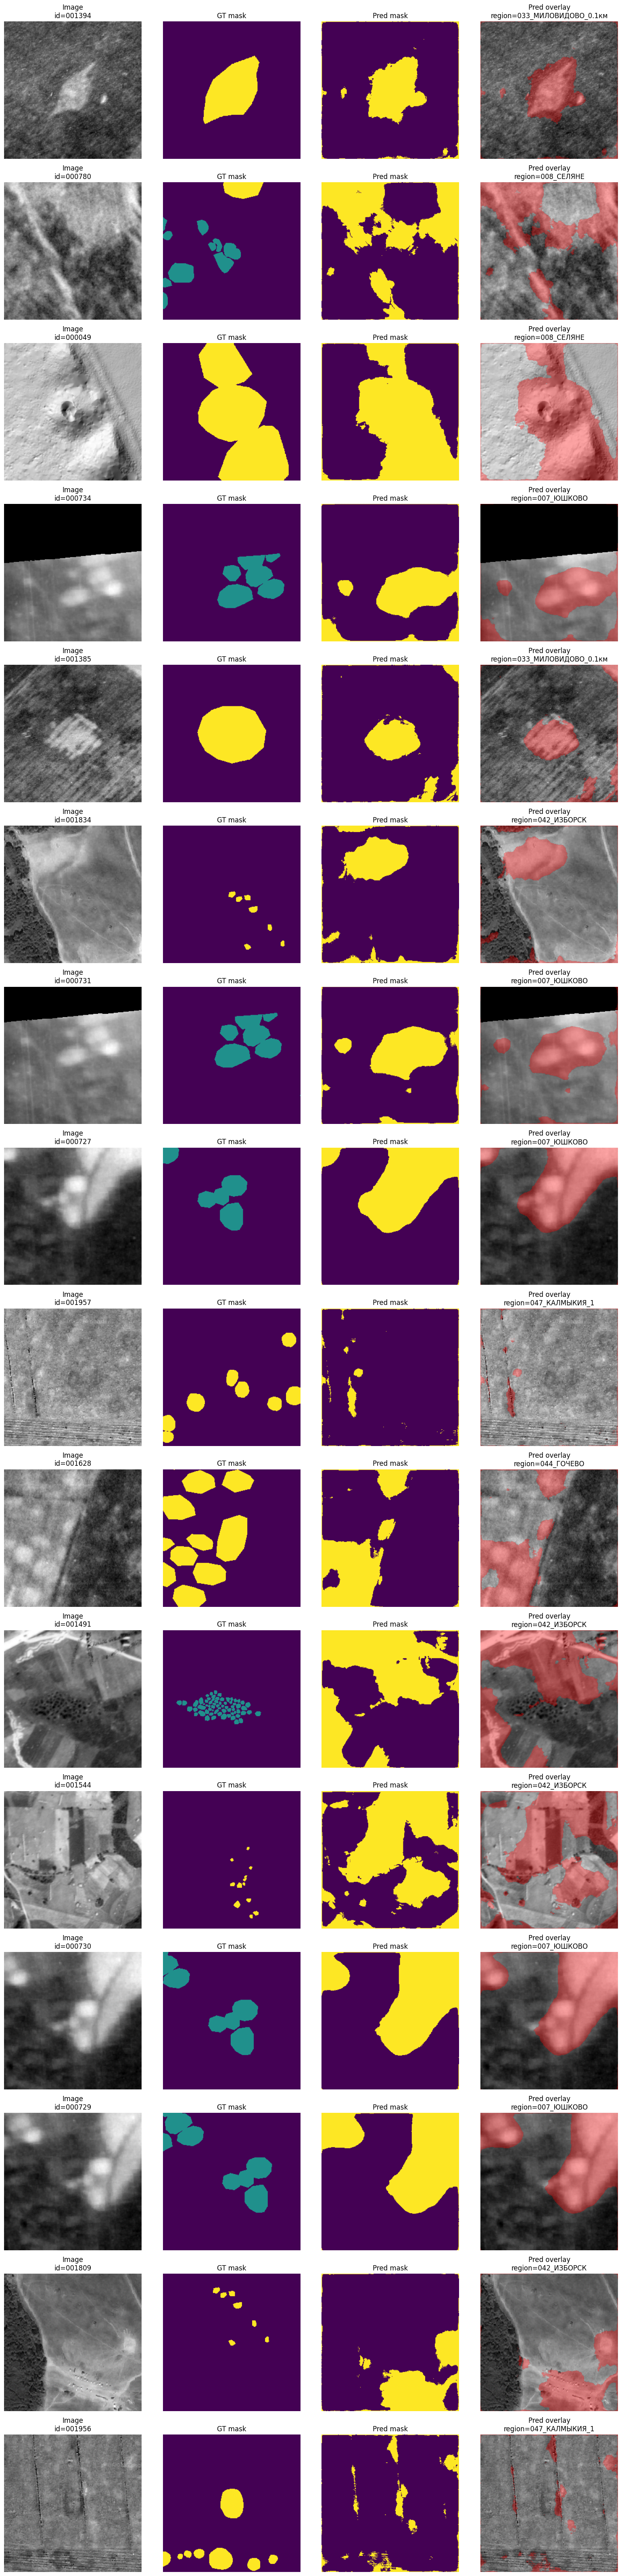

In [ ]:
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader


def denormalize_for_display(img):
    """
    img: numpy array after zscore normalization
    just stretch to [0, 1] for visualization
    """
    img = img.copy()
    img_min = img.min()
    img_max = img.max()
    if img_max - img_min < 1e-6:
        return img * 0.0
    return (img - img_min) / (img_max - img_min)

def mask_to_overlay(mask):
    overlay = np.zeros((*mask.shape, 4), dtype=np.float32)

    # whole = зелёный
    overlay[mask == 1] = [0.0, 1.0, 0.0, 0.35]

    # damaged = красный
    overlay[mask == 2] = [1.0, 0.0, 0.0, 0.35]

    return overlay

def visualize_batch(model, loader, device, max_samples=8, save_path=None):
    model.eval()

    batch = next(iter(loader))
    images = batch["image"].to(device)
    masks = batch["mask"].to(device)

    with torch.no_grad():
        logits = model(images)
        preds = torch.argmax(logits, dim=1)  # [B, H, W]

    images = images.cpu()
    masks = masks.cpu()
    preds = preds.cpu()

    sample_ids = batch["sample_id"]
    regions = batch["region"]

    n = min(max_samples, images.shape[0])
    fig, axes = plt.subplots(n, 4, figsize=(16, 4 * n))

    if n == 1:
        axes = [axes]

    for i in range(n):
        img = images[i, 0].numpy()
        gt = masks[i].numpy()
        pr = preds[i].numpy()

        img_show = denormalize_for_display(img)

        gt_overlay = mask_to_overlay(gt)
        pr_overlay = mask_to_overlay(pr)

        axes[i][0].imshow(img_show, cmap="gray")
        axes[i][0].set_title(f"Image\nid={sample_ids[i]}")
        axes[i][0].axis("off")

        axes[i][1].imshow(gt, vmin=0, vmax=2)
        axes[i][1].set_title("GT mask")
        axes[i][1].axis("off")

        axes[i][2].imshow(pr, vmin=0, vmax=2)
        axes[i][2].set_title("Pred mask")
        axes[i][2].axis("off")

        axes[i][3].imshow(img_show, cmap="gray")
        axes[i][3].imshow(pr_overlay)
        axes[i][3].set_title(f"Pred overlay\nregion={regions[i]}")
        axes[i][3].axis("off")

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Saved visualization to {save_path}")

    plt.show()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

val_dataset = KurganDataset(
        meta_df=val_df,
        images_dir=IMAGES_DIR,
        masks_dir=MASKS_DIR,
        target_size=256,
        normalize="zscore",
    )
val_loader = DataLoader(
        val_dataset,
        batch_size=16,
        shuffle=True,
        num_workers=0
    )

model = UNetSmall(in_channels=1, out_channels=3).to(device)
model.load_state_dict(torch.load("/kaggle/working/unet_multiclass_best.pth", map_location=device))

visualize_batch(
    model=model,
    loader=val_loader,
    device=device,
    max_samples=16,
    save_path="val_predictions.png",
)